In [4]:
from attack_by_group1 import load_pullback_npz, build_groups_from_npz, build_transforms
from torch.utils.data import DataLoader, Subset
from torchvision.datasets import ImageFolder
import os
import torch
import numpy as np
import matplotlib.pyplot as plt
from torchvision.utils import make_grid




pullback_npz = '/home/ethanrao/MIA_LDM/ldm4imagenet/runs/ldm_imnet256/imnetv1_10k_pullback.npz'
data_root = '/data/mingxing/IMNET100K/'

tf = build_transforms(256)
train_full = ImageFolder(os.path.join(data_root, "train"), transform=tf)
val_full   = ImageFolder(os.path.join(data_root, "val"),   transform=tf)

# undo your Normalize([0.5]*3, [0.5]*3)
def _denorm(imgs: torch.Tensor) -> torch.Tensor:
    return torch.clamp(imgs * 0.5 + 0.5, 0.0, 1.0)

def preview_batch(loader, title, idx_to_class, nrow=8, save_path=None):
    imgs, labs = next(iter(loader))            # grab one batch
    print(f"[{title}] batch: imgs={tuple(imgs.shape)}, dtype={imgs.dtype}, "
          f"labs={tuple(labs.shape)}, min={imgs.min().item():.3f}, max={imgs.max().item():.3f}")

    # quick histogram of labels in this batch
    uniq, cnts = np.unique(labs.numpy(), return_counts=True)
    hist_str = ", ".join([f"{idx_to_class[int(u)]}:{int(c)}" for u, c in zip(uniq, cnts)])
    print(f"[{title}] label counts: {hist_str}")

    # denormalize [+ visualize]
    imgs_dn = _denorm(imgs)
    grid = make_grid(imgs_dn, nrow=nrow, padding=2)  # CHW
    grid_np = grid.permute(1, 2, 0).numpy()          # HWC for matplotlib

    rows = (imgs.size(0) + nrow - 1) // nrow
    plt.figure(figsize=(nrow * 1.8, rows * 1.8))
    plt.imshow(grid_np)
    plt.title(f"{title} — batch_size={imgs.size(0)}")
    plt.axis('off')

    if save_path:
        plt.savefig(save_path, bbox_inches='tight')
        print(f"[{title}] saved preview to: {save_path}")
        plt.close()
    else:
        plt.show()

def build_groups_from_npz(npz_path: str, grouping: str, seed: int = 2025, n_random_groups: int = 4):
    d = load_pullback_npz(npz_path)
    m_idx, h_idx = d['member_indices'], d['heldout_indices']
    m_mv, h_mv = d['member_metric'], d['heldout_metric']

    if grouping == 'random':
        rng = np.random.RandomState(seed)
        # create n_random_groups equal-ish splits
        m_perm = rng.permutation(len(m_idx))
        h_perm = rng.permutation(len(h_idx))
        m_groups = [m_idx[m_perm[i::n_random_groups]] for i in range(n_random_groups)]
        h_groups = [h_idx[h_perm[i::n_random_groups]] for i in range(n_random_groups)]
        names = [f"rand{i+1}" for i in range(n_random_groups)]
        print(f"[random] split into {n_random_groups} groups with seed={seed}")
    else:
        union = np.concatenate([m_mv, h_mv], axis=0)
        if grouping == 'median':
            thr = np.median(union)
            names = ['low','high']
            m_groups = [m_idx[m_mv <= thr], m_idx[m_mv > thr]]
            h_groups = [h_idx[h_mv <= thr], h_idx[h_mv > thr]]
            print(f"[threshold] median={thr:.6f}")
        elif grouping == 'quartiles':
            q1, med, q3 = np.percentile(union, [25, 50, 75])
            names = ['q1','q2','q3','q4']
            m_groups = [
                m_idx[m_mv <= q1],
                m_idx[(m_mv > q1) & (m_mv <= med)],
                m_idx[(m_mv > med) & (m_mv <= q3)],
                m_idx[m_mv > q3],
            ]
            h_groups = [
                h_idx[h_mv <= q1],
                h_idx[(h_mv > q1) & (h_mv <= med)],
                h_idx[(h_mv > med) & (h_mv <= q3)],
                h_idx[h_mv > q3],
            ]
            print(f"[thresholds] q1={q1:.6f}  med={med:.6f}  q3={q3:.6f}")
        elif grouping == "extreme":
            k = 32
            m_sorted = np.argsort(m_mv)
            h_sorted = np.argsort(h_mv)
            m_low = m_idx[m_sorted[:k]]
            m_high = m_idx[m_sorted[-k:]]
            h_low = h_idx[h_sorted[:k]]
            h_high = h_idx[h_sorted[-k:]]
            names = [f"lowest{k}", f"highest{k}"]
            m_groups = [m_low, m_high]
            h_groups = [h_low, h_high]
            print(f"[extreme] selected lowest {k} and highest {k} samples per split")
        else:
            raise ValueError("grouping must be 'random'|'median'|'quartiles'")
    for n, mg, hg in zip(names, m_groups, h_groups):
        print(f"Group {n:>6}: members={len(mg)} | heldout={len(hg)}")
    return dict(names=names, member_groups=m_groups, held_groups=h_groups)

# build class name lookups from the *same* datasets used for each loader
idx_to_class_train = {v: k for k, v in train_full.class_to_idx.items()}
idx_to_class_val   = {v: k for k, v in val_full.class_to_idx.items()}

splits = build_groups_from_npz(pullback_npz, 'extreme', seed=2025, n_random_groups=2)

# For each group: build loaders, encode latents, run probe_unet (streaming version)
for name, mem_idx, held_idx in zip(splits['names'], splits['member_groups'], splits['held_groups']):
    if len(mem_idx) == 0 or len(held_idx) == 0:
        print(f"\n=== Group {name} (skipped; empty) ===")
        continue

    print(f"\n=== Group {name} ===")
    m_loader = DataLoader(Subset(train_full, mem_idx.tolist()),
                            batch_size=32, shuffle=False,
                            num_workers=8, pin_memory=True)
    h_loader = DataLoader(Subset(val_full, held_idx.tolist()),
                            batch_size=32, shuffle=False,
                            num_workers=8, pin_memory=True)

    # preview one batch from each
    preview_batch(m_loader, "members/train", idx_to_class_train, nrow=8, save_path=f"members_preview_{name}.png")
    preview_batch(h_loader, "heldout/val",   idx_to_class_val,   nrow=8, save_path=f"heldout_preview_{name}.png")




[extreme] selected lowest 32 and highest 32 samples per split
Group lowest32: members=32 | heldout=32
Group highest32: members=32 | heldout=32

=== Group lowest32 ===
[members/train] batch: imgs=(32, 3, 256, 256), dtype=torch.float32, labs=(32,), min=-1.000, max=1.000
[members/train] label counts: 00005:1, 00006:1, 00080:1, 00086:1, 00111:2, 00126:1, 00149:1, 00236:1, 00266:1, 00274:1, 00350:1, 00353:1, 00478:1, 00482:1, 00508:1, 00601:1, 00631:1, 00653:2, 00712:1, 00811:1, 00812:1, 00844:1, 00885:1, 00910:1, 00940:1, 00951:2, 00954:1, 00985:1, 00999:1
[members/train] saved preview to: members_preview_lowest32.png
[heldout/val] batch: imgs=(32, 3, 256, 256), dtype=torch.float32, labs=(32,), min=-1.000, max=1.000
[heldout/val] label counts: 00001:2, 00004:3, 00005:1, 00107:1, 00228:1, 00258:1, 00260:1, 00296:2, 00314:1, 00358:1, 00362:1, 00369:1, 00374:2, 00419:1, 00440:1, 00504:1, 00584:1, 00629:1, 00666:1, 00680:1, 00752:1, 00906:1, 00940:1, 00951:1, 00952:1, 00965:1, 00980:1
[heldout

Building MNIST row...
Building CIFAR-10 row...
Building CelebA row...
Building ImageNet-1K row...


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).



Saved final composite to: all_extremes_4datasets.svg


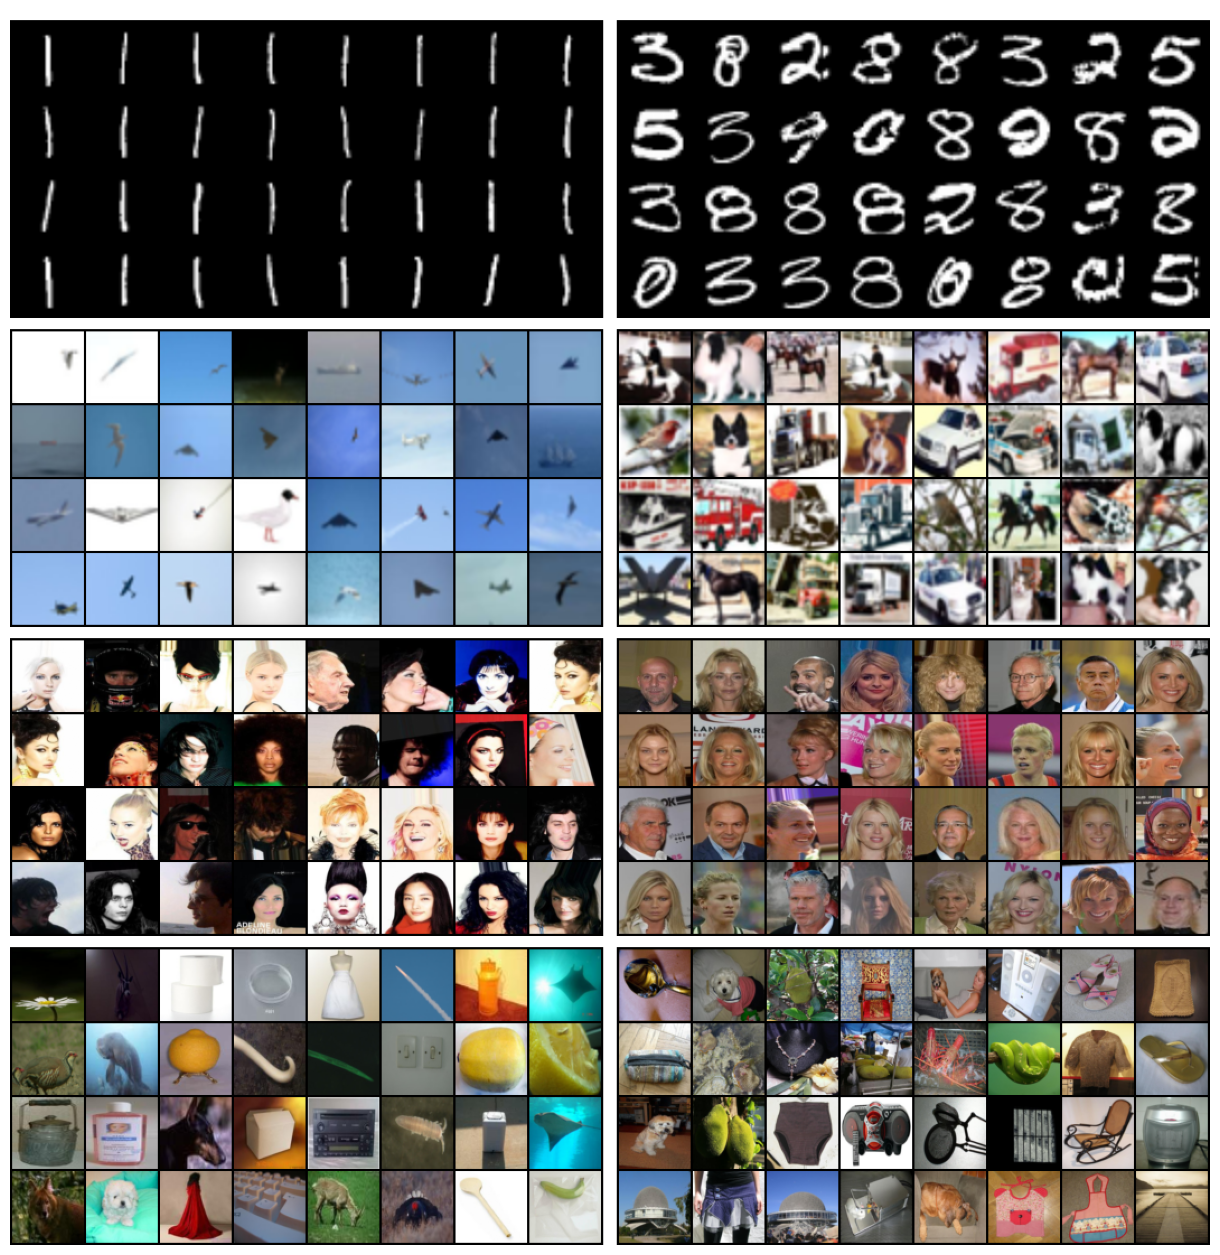

In [1]:
#!/usr/bin/env python3
# -*- coding: utf-8 -*-
import os
import numpy as np
import torch
from torch.utils.data import DataLoader, Subset, Dataset
from torchvision.datasets import MNIST, CIFAR10, ImageFolder
from torchvision import transforms
from torchvision.utils import make_grid
import matplotlib.pyplot as plt
from PIL import Image
import pandas as pd
from attack_by_group_advance import load_pullback_npz

# ================================================================
#                           CONFIG
# ================================================================
preview_size = 64
k_extreme    = 32          # 16 lowest & 16 highest per dataset (2 rows x 8)
batch_size   = k_extreme
num_workers  = 4

# --- dataset npz paths ---
mnist_root  = "/home/ethanrao/MIA_LDM/VAE2Diffusion/data"
mnist_npz   = "/data/mingxing/tmp/MNIST/KL_sweep/1e_2/logvols_mnist_beta_1e_2.npz"

cifar_root  = "/home/ethanrao/MIA_LDM/VAE2Diffusion/data"
cifar_npz   = "/data/mingxing/tmp/CIFAR10/KL_sweep/1e_2/logvols_cifar10_beta_1e_2.npz"

celeba_root = "/home/ethanrao/MIA_LDM/VAE2Diffusion/data/celeba"
celeba_npz  = "/data/mingxing/tmp/CELEBA/KL_sweep/1e_3/logvols_celeba_beta_1e_3.npz"

imagenet_root     = "/data/mingxing/tmp/IMNET100K/data"
imagenet_pull_npz = "/data/mingxing/tmp/IMNET100K/runs/ldm_imnet256_10k/imnetv1_10k_pullback.npz"

save_path = "all_extremes_4datasets.svg"

# ================================================================
#                           TRANSFORMS
# ================================================================
tf_gray = transforms.Compose([
    transforms.Resize((preview_size, preview_size)),
    transforms.ToTensor(),
    transforms.Normalize([0.5], [0.5])
])

tf_rgb = transforms.Compose([
    transforms.Resize((preview_size, preview_size)),
    transforms.ToTensor(),
    transforms.Normalize([0.5, 0.5, 0.5], [0.5, 0.5, 0.5])
])

def _denorm(imgs: torch.Tensor) -> torch.Tensor:
    return torch.clamp(imgs * 0.5 + 0.5, 0.0, 1.0)

# ================================================================
#                       CELEBA DATASET
# ================================================================
class CelebAKaggle(Dataset):
    def __init__(self, root, split="train", transform=None):
        self.root = root
        self.img_dir = os.path.join(root, "img_align_celeba")
        self.part = pd.read_csv(os.path.join(root, "list_eval_partition.csv"))
        self.transform = transform

        split_map = {"train": 0, "valid": 1, "test": 2}
        ids = self.part[self.part["partition"] == split_map[split]]["image_id"]
        self.files = ids.tolist()

    def __len__(self):
        return len(self.files)

    def __getitem__(self, idx):
        img_path = os.path.join(self.img_dir, self.files[idx])
        img = Image.open(img_path).convert("RGB")
        if self.transform:
            img = self.transform(img)
        return img, 0

# ================================================================
#           BUILD A SINGLE DATASET BLOCK (low | high)
# ================================================================
def make_low_high_row(low_imgs, high_imgs, nrow_each=8, spacer_px=12):
    low_dn  = _denorm(low_imgs)
    high_dn = _denorm(high_imgs)

    low_grid  = make_grid(low_dn,  nrow=nrow_each, padding=2)
    high_grid = make_grid(high_dn, nrow=nrow_each, padding=2)

    low_np  = low_grid.permute(1, 2, 0).cpu().numpy()
    high_np = high_grid.permute(1, 2, 0).cpu().numpy()

    if low_np.shape[2] == 1:
        low_np  = np.repeat(low_np,  3, axis=2)
        high_np = np.repeat(high_np, 3, axis=2)

    H, W, _ = low_np.shape
    spacer = np.ones((H, spacer_px, 3), dtype=low_np.dtype)

    return np.concatenate([low_np, spacer, high_np], axis=1)

# ================================================================
#                EXTRACT EXTREMES FOR EACH DATASET
# ================================================================
def get_mnist_row():
    full = MNIST(root=mnist_root, train=True, download=True, transform=tf_gray)
    d = np.load(mnist_npz)
    logv = d["logv_train"]
    idxs = d["train_indices"]
    order = np.argsort(logv)
    k = min(k_extreme, len(idxs))
    low  = idxs[order[:k]]
    high = idxs[order[-k:]]
    L = DataLoader(Subset(full, low.tolist()),  batch_size=k, shuffle=False, num_workers=num_workers, pin_memory=True)
    H = DataLoader(Subset(full, high.tolist()), batch_size=k, shuffle=False, num_workers=num_workers, pin_memory=True)
    low_imgs,  _ = next(iter(L))
    high_imgs, _ = next(iter(H))
    return make_low_high_row(low_imgs, high_imgs, nrow_each=8)

def get_cifar_row():
    full = CIFAR10(root=cifar_root, train=True, download=True, transform=tf_rgb)
    d = np.load(cifar_npz)
    logv = d["logv_train"]
    idxs = d["train_indices"]
    order = np.argsort(logv)
    k = min(k_extreme, len(idxs))
    low  = idxs[order[:k]]
    high = idxs[order[-k:]]
    L = DataLoader(Subset(full, low.tolist()),  batch_size=k, shuffle=False, num_workers=num_workers, pin_memory=True)
    H = DataLoader(Subset(full, high.tolist()), batch_size=k, shuffle=False, num_workers=num_workers, pin_memory=True)
    low_imgs,  _ = next(iter(L))
    high_imgs, _ = next(iter(H))
    return make_low_high_row(low_imgs, high_imgs, nrow_each=8)

def get_celeba_row():
    full = CelebAKaggle(root=celeba_root, split="train", transform=tf_rgb)
    d = np.load(celeba_npz)
    logv = d["logv_train"]
    idxs = d["train_indices"]
    order = np.argsort(logv)
    k = min(k_extreme, len(idxs))
    low  = idxs[order[:k]]
    high = idxs[order[-k:]]
    L = DataLoader(Subset(full, low.tolist()),  batch_size=k, shuffle=False, num_workers=num_workers, pin_memory=True)
    H = DataLoader(Subset(full, high.tolist()), batch_size=k, shuffle=False, num_workers=num_workers, pin_memory=True)
    low_imgs,  _ = next(iter(L))
    high_imgs, _ = next(iter(H))
    return make_low_high_row(low_imgs, high_imgs, nrow_each=8)

def get_imnet_row():
    full = ImageFolder(os.path.join(imagenet_root, "train"), transform=tf_rgb)
    d = load_pullback_npz(imagenet_pull_npz)
    m_idx = d["member_indices"]
    m_mv  = d["member_metric"]
    order = np.argsort(m_mv)
    k = min(k_extreme, len(m_idx))
    low  = m_idx[order[:k]]
    high = m_idx[order[-k:]]
    L = DataLoader(Subset(full, low.tolist()),  batch_size=k, shuffle=False, num_workers=num_workers, pin_memory=True)
    H = DataLoader(Subset(full, high.tolist()), batch_size=k, shuffle=False, num_workers=num_workers, pin_memory=True)
    low_imgs,  _ = next(iter(L))
    high_imgs, _ = next(iter(H))
    return make_low_high_row(low_imgs, high_imgs, nrow_each=8)

# ================================================================
#                     ADD TITLE BAR ABOVE ROW
# ================================================================
def add_title_bar(img, title, bar_height=10):
    H, W, _ = img.shape
    fig = plt.figure(figsize=(W/100, bar_height/100), dpi=100)
    plt.axis("off")
    fig.canvas.draw()
    text_img = np.frombuffer(fig.canvas.tostring_rgb(), dtype=np.uint8)
    text_img = text_img.reshape(bar_height, W, 3)
    plt.close(fig)
    return np.concatenate([text_img, img], axis=0)

# ================================================================
#                     FINAL COMPOSITE BUILD
# ================================================================
print("Building MNIST row...")
row_mnist  = get_mnist_row()
print("Building CIFAR-10 row...")
row_cifar  = get_cifar_row()
print("Building CelebA row...")
row_celeba = get_celeba_row()
print("Building ImageNet-1K row...")
row_imnet  = get_imnet_row()

row_mnist  = add_title_bar(row_mnist,  "MNIST")
row_cifar  = add_title_bar(row_cifar,  "CIFAR-10")
row_celeba = add_title_bar(row_celeba, "CelebA")
row_imnet  = add_title_bar(row_imnet,  "ImageNet-1K")

final = np.concatenate([row_mnist, row_cifar, row_celeba, row_imnet], axis=0)

plt.figure(figsize=(12, 22))
plt.imshow(final)
plt.axis("off")
plt.tight_layout(pad=0)
plt.savefig(save_path, dpi=300, bbox_inches="tight")
print(f"\nSaved final composite to: {save_path}")

all_extremes_4datasets = final


In [ ]:
import os
import numpy as np
from torchvision.datasets import MNIST
from torchvision import transforms
from torch.utils.data import Subset, DataLoader
from torchvision.transforms.functional import to_pil_image

# ------------------------------------------------------------------ config
mnist_root = "/home/ethanrao/MIA_LDM/VAE2Diffusion/data"
mnist_npz  = "/data/mingxing/tmp/MNIST/KL_sweep/1e_2/logvols_mnist_beta_1e_2.npz"
out_dir    = "/data/mingxing/tmp/MNIST/KL_sweep/1e_2/extreme_images"   # <-- change as needed
k          = 32

# ------------------------------------------------------------------ load npz
d     = np.load(mnist_npz)
logv  = d["logv_train"]
idxs  = d["train_indices"]
order = np.argsort(logv)

low_idxs  = idxs[order[:k]]
high_idxs = idxs[order[-k:]]

# ------------------------------------------------------------------ load MNIST (raw 28x28)
full = MNIST(root=mnist_root, train=True, download=False,
             transform=transforms.ToTensor())

# ------------------------------------------------------------------ save helper
def save_subset(dataset, indices, folder, prefix):
    os.makedirs(folder, exist_ok=True)
    loader = DataLoader(Subset(dataset, indices.tolist()),
                        batch_size=len(indices), shuffle=False, num_workers=4)
    imgs, labels = next(iter(loader))
    for i, (img, lbl) in enumerate(zip(imgs, labels)):
        fname = f"{prefix}_{i:03d}_label{int(lbl)}.png"
        to_pil_image(img).save(os.path.join(folder, fname))
    print(f"Saved {len(imgs)} images -> {folder}")

save_subset(full, low_idxs,  os.path.join(out_dir, "low32"),  prefix="low")
save_subset(full, high_idxs, os.path.join(out_dir, "high32"), prefix="high")
